# Imports

In [1]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings("ignore")

# Load Data and Prepare for Modelling

In [2]:
df = pd.read_csv(r"..\..\Data\Main\modelling_dataset.csv")
df['date'] = pd.to_datetime(df['date'])

print(f"Full dataset: {df.shape}")
print(f"Tickers: {df['ticker'].nunique()}")

# Check NaN counts in the columns we need
features = ['sentiment', 'volatility_20d', 'sent_x_vol']
target = 'target'

for col in features + [target, 'next_day_return']:
    print(f"  {col} NaN: {df[col].isna().sum()}")

Full dataset: (589886, 15)
Tickers: 523
  sentiment NaN: 0
  volatility_20d NaN: 10460
  sent_x_vol NaN: 10460
  target NaN: 0
  next_day_return NaN: 523


## Drop Rows with Missing Values

Volatility requires 20 days of history, producing NaN for the first 20 trading days per ticker. Next-day return is unavailable for each ticker's final day. These rows are dropped as they cannot be used for prediction.

In [3]:
model_df = df.dropna(subset=['volatility_20d', 'next_day_return']).copy()

print(f"Rows before: {len(df)}")
print(f"Rows after: {len(model_df)}")
print(f"Rows dropped: {len(df) - len(model_df)} ({(len(df) - len(model_df))/len(df)*100:.1f}%)")
print(f"Tickers: {model_df['ticker'].nunique()}")

Rows before: 589886
Rows after: 578903
Rows dropped: 10983 (1.9%)
Tickers: 523


# Justification

In [11]:
# Check volatile vs calm day distribution in 2020-2021
train_init = model_df[model_df['date'] < '2022-01-01']
print(f"Initial training period (2020-2021):")
print(f"  Total rows: {len(train_init)}")
print(f"  Volatile days: {(train_init['volatile_market'] == 1).sum()} ({(train_init['volatile_market'] == 1).mean()*100:.1f}%)")
print(f"  Calm days: {(train_init['volatile_market'] == 0).sum()} ({(train_init['volatile_market'] == 0).mean()*100:.1f}%)")

Initial training period (2020-2021):
  Total rows: 165150
  Volatile days: 102168 (61.9%)
  Calm days: 62982 (38.1%)


In [12]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

features = ['sentiment', 'volatility_20d', 'sent_x_vol']
target = 'target'

model_df = model_df.sort_values('date').reset_index(drop=True)

model_df['year_month'] = model_df['date'].dt.to_period('M')
all_months = model_df[model_df['date'] >= '2022-01-01']['year_month'].unique()
all_months = sorted(all_months)

print(f"Initial training period: 2020-2021")
print(f"Prediction months: {len(all_months)} (from {all_months[0]} to {all_months[-1]})")
print(f"Features: {features}")

Initial training period: 2020-2021
Prediction months: 48 (from 2022-01 to 2025-12)
Features: ['sentiment', 'volatility_20d', 'sent_x_vol']


 ## Run Walk-Forward Logistic Regression

In [13]:
monthly_results = []

for month in all_months:
    # Training data: everything before this month
    train = model_df[model_df['year_month'] < month]
    # Test data: this month only
    test = model_df[model_df['year_month'] == month]
    
    X_train = train[features]
    y_train = train[target]
    X_test = test[features]
    y_test = test[target]
    
    # Train logistic regression
    lr = LogisticRegression(max_iter=1000, random_state=42)
    lr.fit(X_train, y_train)
    
    # Predict
    y_pred = lr.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    
    monthly_results.append({
        'month': str(month),
        'accuracy': acc,
        'test_size': len(test),
        'train_size': len(train)
    })
    
    print(f"{month}: accuracy={acc:.4f}, test={len(test)}, train={len(train)}")

results_df = pd.DataFrame(monthly_results)
print(f"\nOverall mean accuracy: {results_df['accuracy'].mean():.4f}")
print(f"Baseline (always predict up): 0.5173")

2022-01: accuracy=0.4459, test=8435, train=165150
2022-02: accuracy=0.4434, test=8253, train=173585
2022-03: accuracy=0.5699, test=10082, train=181838
2022-04: accuracy=0.4522, test=8514, train=191920
2022-05: accuracy=0.5210, test=8744, train=200434
2022-06: accuracy=0.4557, test=8877, train=209178
2022-07: accuracy=0.5600, test=8132, train=218055
2022-08: accuracy=0.4885, test=9546, train=226187
2022-09: accuracy=0.4112, test=8827, train=235733
2022-10: accuracy=0.5297, test=8649, train=244560
2022-11: accuracy=0.5590, test=8689, train=253209
2022-12: accuracy=0.4421, test=8707, train=261898
2023-01: accuracy=0.5936, test=8221, train=270605
2023-02: accuracy=0.4230, test=8040, train=278826
2023-03: accuracy=0.5333, test=9774, train=286866
2023-04: accuracy=0.5181, test=7916, train=296640
2023-05: accuracy=0.4542, test=9232, train=304556
2023-06: accuracy=0.5755, test=8933, train=313788
2023-07: accuracy=0.5518, test=8235, train=322721
2023-08: accuracy=0.4758, test=9887, train=330956

## Extract Coefficients and Statistical Significance

In [14]:
import statsmodels.api as sm

# Train on full 2020-2021 for the coefficient analysis
train_full = model_df[model_df['date'] < '2022-01-01']

X = train_full[features]
X = sm.add_constant(X)  # Add intercept
y = train_full[target]

logit_model = sm.Logit(y, X).fit()
print(logit_model.summary())

Optimization terminated successfully.
         Current function value: 0.691662
         Iterations 4
                           Logit Regression Results                           
Dep. Variable:                 target   No. Observations:               165150
Model:                          Logit   Df Residuals:                   165146
Method:                           MLE   Df Model:                            3
Date:                Thu, 30 Apr 2026   Pseudo R-squ.:               6.996e-05
Time:                        06:28:27   Log-Likelihood:            -1.1423e+05
converged:                       True   LL-Null:                   -1.1424e+05
Covariance Type:            nonrobust   LLR p-value:                  0.001142
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
const              0.1232      0.009     14.413      0.000       0.106       0.140
sentiment        

## Interpretation of Logistic Regression Results

### Model Fit
The model was trained on 165,150 observations from 2020–2021. The LLR p-value of 0.001 indicates the model as a whole is meaningful — the features are providing some useful information. The Pseudo R-squared is very low (0.00007), but this is normal when trying to predict daily stock movements. Stock prices are extremely unpredictable on a day-to-day basis, so even a small amount of useful information is considered a positive result.

### What Each Result Means

**Intercept (0.1232, p < 0.001):**
This is the model's starting point. The positive value reflects the fact that stocks in the dataset went up 51.7% of the time — slightly more often than they went down.

**Sentiment (-0.0347, p = 0.200):**
This result indicates that sentiment alone does not help predict whether a stock goes up or down tomorrow. The p-value of 0.200 is above 0.05, meaning there is no strong evidence that knowing today's news sentiment helps with tomorrow's prediction. This is consistent with the EDA, which showed no clear pattern between sentiment and next-day returns when looking at all market conditions together.

**Volatility (-0.6322, p = 0.019):**
This result indicates that volatility does have an effect on its own. The negative value means that when a stock has been more volatile recently, it is slightly more likely to go down the next day.

**Sentiment × Volatility Interaction (2.4098, p = 0.006):**
This is the most important result in the study. The p-value of 0.006 is well below the 0.05 threshold, indicating strong evidence that this effect is real and not due to chance.

This result indicates that volatility changes how useful sentiment is. When volatility is low, sentiment does not help much — the model mostly ignores it. When volatility is high, sentiment becomes a much stronger signal that the model can use.

Think of it this way: sentiment is like advice from a friend. On a normal, quiet day, the advice does not really change what happens. But on a chaotic, stressful day, that same advice suddenly matters a lot more and influences decisions.

### What This Means for the Research Question
The research question asks: does volatility moderate the predictive power of sentiment?

The results indicate that it does:

- Sentiment alone is not a significant predictor (p = 0.200). Knowing today's news does not reliably tell us what happens tomorrow.
- But sentiment combined with volatility is significant (p = 0.006). When the market is volatile, today's news becomes a useful signal for predicting tomorrow's direction.

This is what moderation means — volatility does not predict returns on its own in a useful way, and sentiment does not predict returns on its own. But when they work together during volatile periods, they become meaningful.

### About the Overall Accuracy
The walk-forward validation gave an average accuracy of 51.4%, which is slightly below the 51.7% baseline of just always guessing "up." This might look like the model is not working, but accuracy was not the purpose of this model.

The logistic regression was used to answer one question: is the interaction between sentiment and volatility statistically significant? The answer is yes (p = 0.006). The low accuracy simply reflects the reality that predicting daily stock movements is extremely difficult — even the best models in published research rarely get much above 55%.

The next steps — the split-sample analysis and the LSTM model — will test whether this finding can be turned into better predictions when the model treats volatile and calm markets separately.

## Split-Sample Analysis: Volatile vs Calm Markets
The same walk-forward logistic regression is applied, but test-month predictions are evaluated separately for volatile and calm market days. If volatility moderates sentiment's predictive power, accuracy should be higher during volatile periods.

In [15]:
volatile_results = []
calm_results = []

for month in all_months:
    train = model_df[model_df['year_month'] < month]
    test = model_df[model_df['year_month'] == month]
    
    X_train = train[features]
    y_train = train[target]
    
    # Train one model on all data
    lr = LogisticRegression(max_iter=1000, random_state=42)
    lr.fit(X_train, y_train)
    
    # Split test into volatile and calm
    test_vol = test[test['volatile_market'] == 1]
    test_calm = test[test['volatile_market'] == 0]
    
    if len(test_vol) > 0:
        pred_vol = lr.predict(test_vol[features])
        acc_vol = accuracy_score(test_vol[target], pred_vol)
        volatile_results.append({'month': str(month), 'accuracy': acc_vol, 'test_size': len(test_vol)})
    
    if len(test_calm) > 0:
        pred_calm = lr.predict(test_calm[features])
        acc_calm = accuracy_score(test_calm[target], pred_calm)
        calm_results.append({'month': str(month), 'accuracy': acc_calm, 'test_size': len(test_calm)})

vol_df = pd.DataFrame(volatile_results)
calm_df = pd.DataFrame(calm_results)

print(f"=== Volatile Markets ===")
print(f"Months with volatile days: {len(vol_df)}")
print(f"Mean accuracy: {vol_df['accuracy'].mean():.4f}")

print(f"\n=== Calm Markets ===")
print(f"Months with calm days: {len(calm_df)}")
print(f"Mean accuracy: {calm_df['accuracy'].mean():.4f}")

print(f"\nDifference: {vol_df['accuracy'].mean() - calm_df['accuracy'].mean():.4f}")
print(f"Baseline (always predict up): 0.5173")

=== Volatile Markets ===
Months with volatile days: 34
Mean accuracy: 0.5310

=== Calm Markets ===
Months with calm days: 35
Mean accuracy: 0.5051

Difference: 0.0259
Baseline (always predict up): 0.5173


## Visualise Accuracy by Market Regime

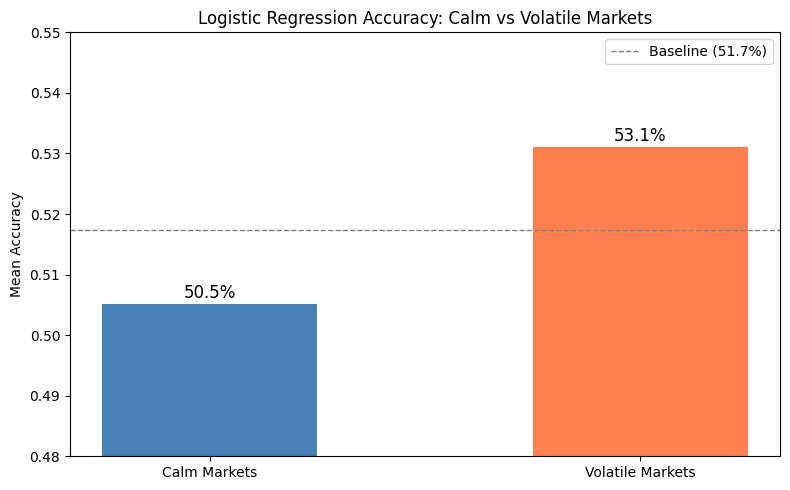

In [17]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.bar(['Calm Markets', 'Volatile Markets'], 
              [calm_df['accuracy'].mean(), vol_df['accuracy'].mean()],
              color=['steelblue', 'coral'], width=0.5)

ax.axhline(y=0.5173, color='grey', linestyle='--', linewidth=1, label='Baseline (51.7%)')
ax.set_ylabel('Mean Accuracy')
ax.set_title('Logistic Regression Accuracy: Calm vs Volatile Markets')
ax.legend()
ax.set_ylim(0.48, 0.55)

for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.001,
            f'{height:.1%}', ha='center', fontsize=12)

plt.tight_layout()
plt.savefig(r"..\..\EDA\lr_accuracy_by_regime.png", dpi=150)
plt.show()

## Comprehensive Evaluation Metrics

Beyond accuracy, multiple evaluation metrics are used to assess model performance from different angles. Basic metrics (precision, recall, F1) evaluate prediction quality. Advanced metrics (AUC-ROC, MCC, log loss, Cohen's Kappa) provide more robust assessment that accounts for class imbalance and prediction confidence.

In [18]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              matthews_corrcoef, cohen_kappa_score, log_loss, 
                              roc_auc_score, confusion_matrix)

def evaluate_predictions(y_true, y_pred, y_prob=None):
    """Calculate all evaluation metrics."""
    metrics = {
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred),
        'Recall': recall_score(y_true, y_pred),
        'F1 Score': f1_score(y_true, y_pred),
        'MCC': matthews_corrcoef(y_true, y_pred),
        'Cohen Kappa': cohen_kappa_score(y_true, y_pred),
    }
    
    if y_prob is not None:
        metrics['AUC-ROC'] = roc_auc_score(y_true, y_prob)
        metrics['Log Loss'] = log_loss(y_true, y_prob)
    
    return metrics

print("Evaluation function defined.")

Evaluation function defined.


In [19]:
all_y_true = []
all_y_pred = []
all_y_prob = []
all_volatile = []
monthly_metrics = []

for month in all_months:
    train = model_df[model_df['year_month'] < month]
    test = model_df[model_df['year_month'] == month]
    
    X_train = train[features]
    y_train = train[target]
    X_test = test[features]
    y_test = test[target]
    
    lr = LogisticRegression(max_iter=1000, random_state=42)
    lr.fit(X_train, y_train)
    
    y_pred = lr.predict(X_test)
    y_prob = lr.predict_proba(X_test)[:, 1]  # Probability of class 1 (up)
    
    all_y_true.extend(y_test.values)
    all_y_pred.extend(y_pred)
    all_y_prob.extend(y_prob)
    all_volatile.extend(test['volatile_market'].values)

# Convert to arrays
all_y_true = np.array(all_y_true)
all_y_pred = np.array(all_y_pred)
all_y_prob = np.array(all_y_prob)
all_volatile = np.array(all_volatile)

print("Walk-forward predictions collected.")
print(f"Total predictions: {len(all_y_true)}")

Walk-forward predictions collected.
Total predictions: 413753


In [20]:
overall_metrics = evaluate_predictions(all_y_true, all_y_pred, all_y_prob)

print("=== Overall Logistic Regression Metrics ===\n")
for name, value in overall_metrics.items():
    print(f"  {name:<15} {value:.4f}")

print(f"\n=== Confusion Matrix ===")
cm = confusion_matrix(all_y_true, all_y_pred)
print(f"                 Predicted Down  Predicted Up")
print(f"  Actual Down    {cm[0][0]:>12}  {cm[0][1]:>12}")
print(f"  Actual Up      {cm[1][0]:>12}  {cm[1][1]:>12}")

=== Overall Logistic Regression Metrics ===

  Accuracy        0.5140
  Precision       0.5141
  Recall          0.9997
  F1 Score        0.6790
  MCC             -0.0041
  Cohen Kappa     -0.0001
  AUC-ROC         0.4846
  Log Loss        0.6931

=== Confusion Matrix ===
                 Predicted Down  Predicted Up
  Actual Down              42        200993
  Actual Up                74        212644


Metrics Split by Volatile vs Calm:

In [21]:
vol_mask = all_volatile == 1
calm_mask = all_volatile == 0

vol_metrics = evaluate_predictions(all_y_true[vol_mask], all_y_pred[vol_mask], all_y_prob[vol_mask])
calm_metrics = evaluate_predictions(all_y_true[calm_mask], all_y_pred[calm_mask], all_y_prob[calm_mask])

print(f"{'Metric':<15} {'Overall':>10} {'Volatile':>10} {'Calm':>10}")
print("-" * 48)

all_metrics = evaluate_predictions(all_y_true, all_y_pred, all_y_prob)
for name in all_metrics:
    print(f"{name:<15} {all_metrics[name]:>10.4f} {vol_metrics[name]:>10.4f} {calm_metrics[name]:>10.4f}")

print(f"\nBaseline accuracy: 0.5173")

Metric             Overall   Volatile       Calm
------------------------------------------------
Accuracy            0.5140     0.5213     0.5080
Precision           0.5141     0.5213     0.5081
Recall              0.9997     0.9998     0.9995
F1 Score            0.6790     0.6853     0.6737
MCC                -0.0041     0.0048    -0.0119
Cohen Kappa        -0.0001     0.0002    -0.0004
AUC-ROC             0.4846     0.4813     0.4849
Log Loss            0.6931     0.6926     0.6934

Baseline accuracy: 0.5173


In [22]:
print("=== Volatile Markets Confusion Matrix ===")
cm_vol = confusion_matrix(all_y_true[vol_mask], all_y_pred[vol_mask])
print(f"                 Predicted Down  Predicted Up")
print(f"  Actual Down    {cm_vol[0][0]:>12}  {cm_vol[0][1]:>12}")
print(f"  Actual Up      {cm_vol[1][0]:>12}  {cm_vol[1][1]:>12}")
print(f"  Total predictions: {vol_mask.sum()}")
print(f"  Predicted 'down': {cm_vol[0][0] + cm_vol[1][0]}")

print(f"\n=== Calm Markets Confusion Matrix ===")
cm_calm = confusion_matrix(all_y_true[calm_mask], all_y_pred[calm_mask])
print(f"                 Predicted Down  Predicted Up")
print(f"  Actual Down    {cm_calm[0][0]:>12}  {cm_calm[0][1]:>12}")
print(f"  Actual Up      {cm_calm[1][0]:>12}  {cm_calm[1][1]:>12}")
print(f"  Total predictions: {calm_mask.sum()}")
print(f"  Predicted 'down': {cm_calm[0][0] + cm_calm[1][0]}")

=== Volatile Markets Confusion Matrix ===
                 Predicted Down  Predicted Up
  Actual Down              34         89969
  Actual Up                21         97983
  Total predictions: 188007
  Predicted 'down': 55

=== Calm Markets Confusion Matrix ===
                 Predicted Down  Predicted Up
  Actual Down               8        111024
  Actual Up                53        114661
  Total predictions: 225746
  Predicted 'down': 61


 We use class weights to force the model to take both classes seriously. Without class weights, the model learns that predicting "up" every time gets 51.7% accuracy with minimal effort, so it's lazy. Class weights penalise it more heavily for missing "down" days, forcing it to actually try to distinguish between the tw

In [23]:
all_y_true = []
all_y_pred = []
all_y_prob = []
all_volatile = []

for month in all_months:
    train = model_df[model_df['year_month'] < month]
    test = model_df[model_df['year_month'] == month]
    
    X_train = train[features]
    y_train = train[target]
    X_test = test[features]
    y_test = test[target]
    
    # class_weight='balanced' penalises the model for ignoring the minority class
    lr = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
    lr.fit(X_train, y_train)
    
    y_pred = lr.predict(X_test)
    y_prob = lr.predict_proba(X_test)[:, 1]
    
    all_y_true.extend(y_test.values)
    all_y_pred.extend(y_pred)
    all_y_prob.extend(y_prob)
    all_volatile.extend(test['volatile_market'].values)

all_y_true = np.array(all_y_true)
all_y_pred = np.array(all_y_pred)
all_y_prob = np.array(all_y_prob)
all_volatile = np.array(all_volatile)

print("Walk-forward with balanced class weights complete.")
print(f"Total predictions: {len(all_y_true)}")
print(f"Predicted 'up': {(all_y_pred == 1).sum()}")
print(f"Predicted 'down': {(all_y_pred == 0).sum()}")

Walk-forward with balanced class weights complete.
Total predictions: 413753
Predicted 'up': 224598
Predicted 'down': 189155


In [24]:
# Overall metrics
overall_metrics = evaluate_predictions(all_y_true, all_y_pred, all_y_prob)

print("=== Overall Logistic Regression Metrics (Balanced) ===\n")
for name, value in overall_metrics.items():
    print(f"  {name:<15} {value:.4f}")

print(f"\n=== Confusion Matrix ===")
cm = confusion_matrix(all_y_true, all_y_pred)
print(f"                 Predicted Down  Predicted Up")
print(f"  Actual Down    {cm[0][0]:>12}  {cm[0][1]:>12}")
print(f"  Actual Up      {cm[1][0]:>12}  {cm[1][1]:>12}")

# Split by regime
vol_mask = all_volatile == 1
calm_mask = all_volatile == 0

vol_metrics = evaluate_predictions(all_y_true[vol_mask], all_y_pred[vol_mask], all_y_prob[vol_mask])
calm_metrics = evaluate_predictions(all_y_true[calm_mask], all_y_pred[calm_mask], all_y_prob[calm_mask])

print(f"\n{'Metric':<15} {'Overall':>10} {'Volatile':>10} {'Calm':>10}")
print("-" * 48)
for name in overall_metrics:
    print(f"{name:<15} {overall_metrics[name]:>10.4f} {vol_metrics[name]:>10.4f} {calm_metrics[name]:>10.4f}")

print(f"\nBaseline accuracy: 0.5173")

=== Overall Logistic Regression Metrics (Balanced) ===

  Accuracy        0.5038
  Precision       0.5165
  Recall          0.5454
  F1 Score        0.5306
  MCC             0.0053
  Cohen Kappa     0.0052
  AUC-ROC         0.5014
  Log Loss        0.6932

=== Confusion Matrix ===
                 Predicted Down  Predicted Up
  Actual Down           92448        108587
  Actual Up             96707        116011

Metric             Overall   Volatile       Calm
------------------------------------------------
Accuracy            0.5038     0.5043     0.5034
Precision           0.5165     0.5242     0.5105
Recall              0.5454     0.5319     0.5569
F1 Score            0.5306     0.5280     0.5327
MCC                 0.0053     0.0061     0.0051
Cohen Kappa         0.0052     0.0061     0.0051
AUC-ROC             0.5014     0.5001     0.5026
Log Loss            0.6932     0.6931     0.6932

Baseline accuracy: 0.5173
